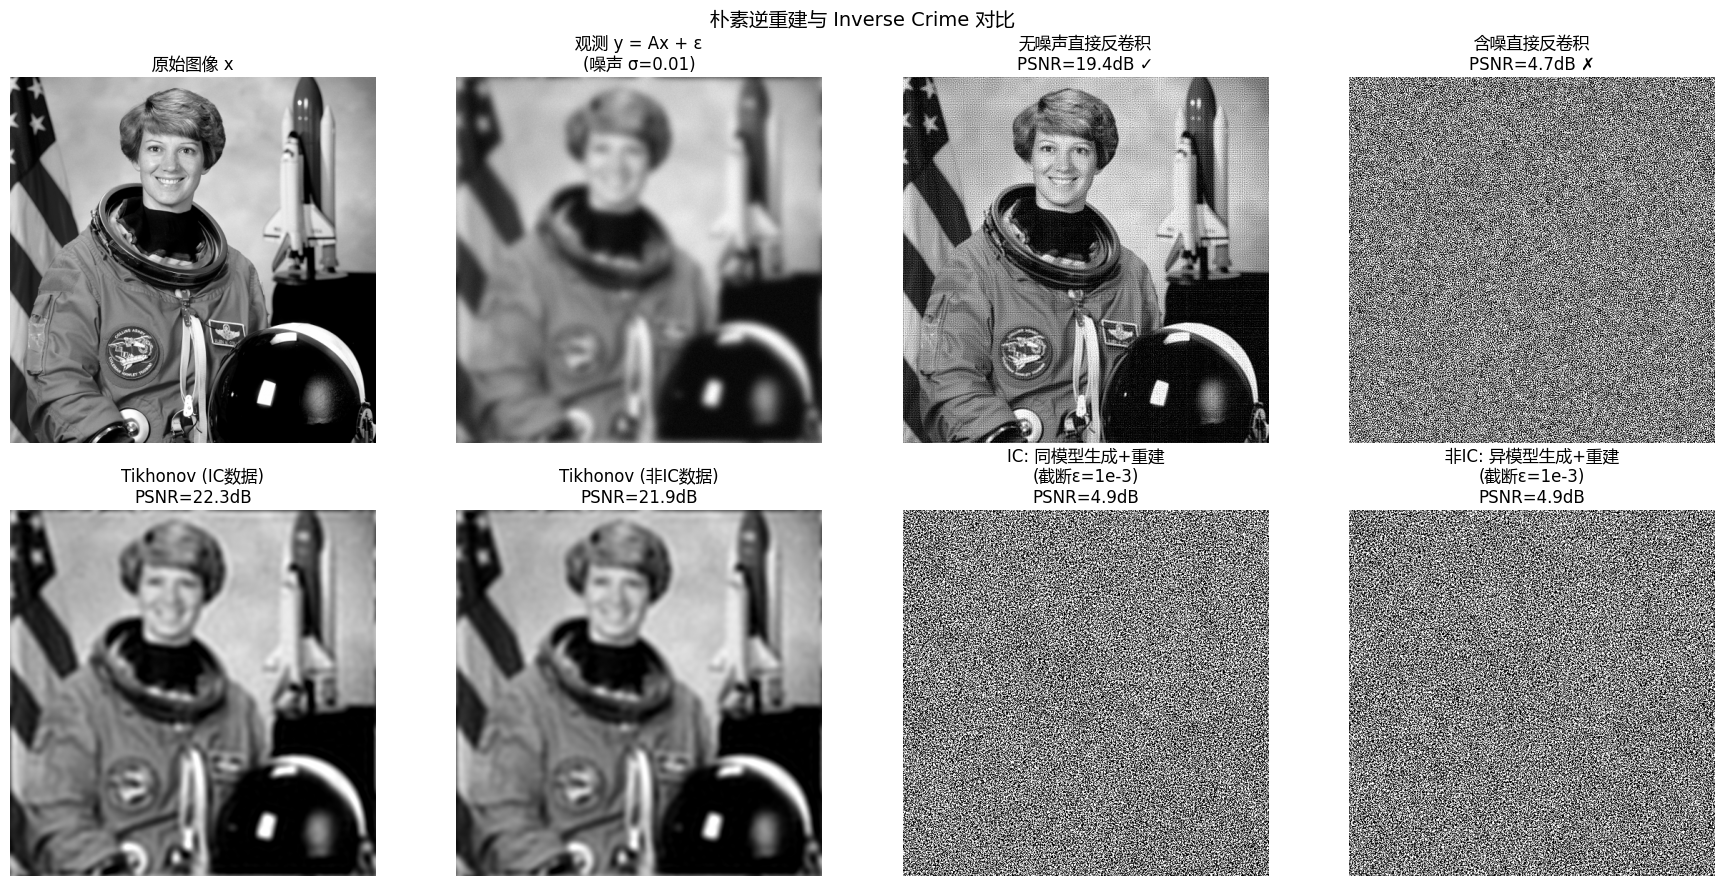


=== Inverse Crime 警示 ===
同模型(σ=5.0)生成 + 重建 → PSNR=22.3dB
异模型(σ=5.3)生成 + 重建 → PSNR=21.9dB
PSNR 差异来自建模误差（PSF 宽度仅差 0.3），这正是 Inverse Crime 掩盖的真相！


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage.data import astronaut
from skimage.color import rgb2gray
from skimage.transform import resize
import matplotlib as mpl

# ====== 解决中文乱码的核心代码 ======
plt.rcParams['font.family'] = ['DejaVu Sans', 'Microsoft YaHei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号
# ========================================================

np.random.seed(42)

# ---- 1. 准备图像和模糊算子 ----
x_color = astronaut()
x = rgb2gray(x_color)
n = x.shape[0]

def gaussian_psf(size, sigma):
    ax = np.concatenate((np.arange(0, size // 2), np.arange(-size // 2, 0)))
    xx, yy = np.meshgrid(ax, ax)
    h = np.exp(-(xx ** 2 + yy ** 2) / (2 * sigma ** 2))
    return h / h.sum()

def blur(x, h):
    return np.real(np.fft.ifft2(np.fft.fft2(h) * np.fft.fft2(x)))

# 两个不同的 PSF：用于 Inverse Crime 对比
sigma_A = 5.0   # 重建模型使用的 PSF 宽度
sigma_B = 5.3   # 数据生成时使用的 PSF 宽度（微有差异，模拟建模误差）

h_A = gaussian_psf(n, sigma_A)  # 重建模型
h_B = gaussian_psf(n, sigma_B)  # "真实"模型

# ---- 2. 生成观测数据 ----
noise_sigma = 0.01  # 噪声水平

# (a) Inverse Crime 数据：用 h_A 生成
y_IC = blur(x, h_A) + noise_sigma * np.random.randn(n, n)

# (b) 非 Inverse Crime 数据：用 h_B 生成
y_noIC = blur(x, h_B) + noise_sigma * np.random.randn(n, n)

# ---- 3. 朴素逆重建（频域直接除法）----
H_A = np.fft.fft2(h_A)
eps_reg = 1e-15  # 无正则化

def naive_deconv(y, H, eps=1e-15):
    """频域直接反卷积：x = F^{-1}(F(y)/H)"""
    return np.real(np.fft.ifft2(np.fft.fft2(y) / (H + eps)))

# ---- 4. Tikhonov 正则化反卷积 ----
def tikhonov_deconv(y, H, lam):
    """Tikhonov 正则化反卷积：x = F^{-1}(H*/(|H|^2+λ) * F(y))"""
    H_star = np.conj(H)
    H_sq = np.abs(H) ** 2
    return np.real(np.fft.ifft2(H_star / (H_sq + lam) * np.fft.fft2(y)))

# ---- 5. 计算重建结果 ----
from skimage.metrics import peak_signal_noise_ratio

# 无噪声直接反卷积（理想情况）
y_clean = blur(x, h_A)
x_naive_clean = naive_deconv(y_clean, H_A)

# Inverse Crime：同模型生成+重建
x_naive_IC = naive_deconv(y_IC, H_A)
x_tikh_IC = tikhonov_deconv(y_IC, H_A, lam=1e-2)

# 非 Inverse Crime：异模型生成+重建
x_naive_noIC = naive_deconv(y_noIC, H_A)
x_tikh_noIC = tikhonov_deconv(y_noIC, H_A, lam=1e-2)

# ---- 6. 可视化 ----
fig, axes = plt.subplots(2, 4, figsize=(18, 9))

axes[0, 0].imshow(x, cmap='gray')
axes[0, 0].set_title('原始图像 x')
axes[0, 0].axis('off')

axes[0, 1].imshow(y_IC, cmap='gray')
axes[0, 1].set_title('观测 y = Ax + ε\n(噪声 σ=0.01)')
axes[0, 1].axis('off')

axes[0, 2].imshow(np.clip(x_naive_clean, 0, 1), cmap='gray')
axes[0, 2].set_title(f'无噪声直接反卷积\nPSNR={peak_signal_noise_ratio(x, np.clip(x_naive_clean,0,1)):.1f}dB ✓')
axes[0, 2].axis('off')

axes[0, 3].imshow(np.clip(x_naive_IC, 0, 1), cmap='gray')
psnr_naive = peak_signal_noise_ratio(x, np.clip(x_naive_IC, 0, 1))
axes[0, 3].set_title(f'含噪直接反卷积\nPSNR={psnr_naive:.1f}dB ✗')
axes[0, 3].axis('off')

axes[1, 0].imshow(np.clip(x_tikh_IC, 0, 1), cmap='gray')
axes[1, 0].set_title(f'Tikhonov (IC数据)\nPSNR={peak_signal_noise_ratio(x, np.clip(x_tikh_IC,0,1)):.1f}dB')
axes[1, 0].axis('off')

axes[1, 1].imshow(np.clip(x_tikh_noIC, 0, 1), cmap='gray')
axes[1, 1].set_title(f'Tikhonov (非IC数据)\nPSNR={peak_signal_noise_ratio(x, np.clip(x_tikh_noIC,0,1)):.1f}dB')
axes[1, 1].axis('off')

# Inverse Crime 对比：朴素重建
axes[1, 2].imshow(np.clip(naive_deconv(y_IC, H_A, eps=1e-3), 0, 1), cmap='gray')
axes[1, 2].set_title(f'IC: 同模型生成+重建\n(截断ε=1e-3)\nPSNR={peak_signal_noise_ratio(x, np.clip(naive_deconv(y_IC, H_A, eps=1e-3),0,1)):.1f}dB')
axes[1, 2].axis('off')

axes[1, 3].imshow(np.clip(naive_deconv(y_noIC, H_A, eps=1e-3), 0, 1), cmap='gray')
axes[1, 3].set_title(f'非IC: 异模型生成+重建\n(截断ε=1e-3)\nPSNR={peak_signal_noise_ratio(x, np.clip(naive_deconv(y_noIC, H_A, eps=1e-3),0,1)):.1f}dB')
axes[1, 3].axis('off')

plt.suptitle('朴素逆重建与 Inverse Crime 对比', fontsize=14)
plt.tight_layout()
plt.savefig('实验1_5_不适定性与InverseCrime.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n=== Inverse Crime 警示 ===")
print(f"同模型(σ={sigma_A})生成 + 重建 → PSNR={peak_signal_noise_ratio(x, np.clip(x_tikh_IC,0,1)):.1f}dB")
print(f"异模型(σ={sigma_B})生成 + 重建 → PSNR={peak_signal_noise_ratio(x, np.clip(x_tikh_noIC,0,1)):.1f}dB")
print("PSNR 差异来自建模误差（PSF 宽度仅差 0.3），这正是 Inverse Crime 掩盖的真相！")